# データ確認

In [3]:
# インポート

# 数値計算
import numpy as np
import pandas as pd

# 統計計算
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Meiryo'  # または import japanize_matplotlib

In [5]:
data = pd.read_csv('./data/3/data3a.csv')
print('data.shape: ', data.shape)
data.head()

data.shape:  (100, 3)


,y,x,f
0,6,8.31,C
1,6,9.44,C
2,6,9.50,C
3,12,9.07,C
4,10,10.16,C


In [6]:
# dataの列ごとにデータを表示 p.42, 43

# x列（体サイズ）
print(data['x'].values)

[ 8.31  9.44  9.5   9.07 10.16  8.32 10.61 10.06  9.93 10.43 10.36 10.15
 10.92  8.85  9.42 11.11  8.02 11.93  8.55  7.19  9.83 10.79  8.89 10.09
 11.63 10.21  9.45 10.44  9.44 10.48  9.43 10.32 10.33  8.5   9.41  8.96
  9.67 10.26 10.36 11.8  10.94 10.25  8.74 10.46  9.37  9.74  8.95  8.74
 11.32  9.25 10.14  9.05  9.89  8.76 12.04  9.91  9.84 11.87 10.16  9.34
 10.17 10.99  9.19 10.67 10.96 10.55  9.69 10.91  9.6  12.37 10.54 11.3
 12.4  10.18  9.53 10.24 11.76  9.52 10.4   9.96 10.3  11.54  9.42 11.28
  9.73 10.78 10.21 10.51 10.73  8.85 11.2   9.86 11.54 10.03 11.88  9.15
  8.52 10.24 10.86  9.97]


In [7]:
# y列（種子数）
print(data['y'].values)

[ 6  6  6 12 10  4  9  9  9 11  6 10  6 10 11  8  3  8  5  5  4 11  5 10
  6  6  7  9  3 10  2  9 10  5 11 10  4  8  9 12  8  9  8  6  6 10 10  9
 12  6 14  6  7  9  6  7  9 13  9 13  7  8 10  7 12  6 15  3  4  6 10  8
  8  7  5  6  8  9  9  6  7 10  6 11 11 11  5  6  4  5  6  5  8  5  9  8
  6  8  7  9]


In [8]:
# f列（施肥処理）　※因子型ではありません
print(data['f'].values) 

['C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C'
 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C'
 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'T' 'T' 'T' 'T'
 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T'
 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T'
 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T']


In [12]:
# 列ごとの型を確認 p.43, 44
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       100 non-null    int64  
 1   x       100 non-null    float64
 2   f       100 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 2.5+ KB


In [14]:
# データフレームの概要を調べる 数値型：要約統計量の表示 p.44
data.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
y,100.0,7.830,2.625,2.00,6.000,8.000,10.000,15.0
x,100.0,10.089,1.008,7.19,9.428,10.155,10.685,12.4


In [15]:
# 分散を調べる
data.var(ddof=1, numeric_only=True).to_frame(name='分散').round(3)

,分散
y,6.890
x,1.016


In [16]:
# データフレームの概要を調べる 文字列型：要素ごとの個数のカウント p.44
data['f'].value_counts().to_frame()

,count
f,
C,50
T,50


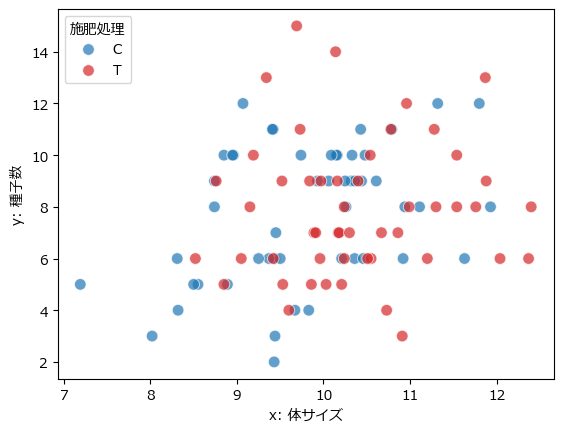

In [17]:
# 散布図の描画 p.45 図3.2

# 散布図の描画（hueで施肥処理有無を設定）
sns.scatterplot(data=data, x='x', y='y', hue='f', 
                palette=['tab:blue', 'tab:red'], s=70, alpha=0.7)
# 修飾：x軸・y軸ラベル、凡例
plt.gca().set(xlabel='x: 体サイズ', ylabel='y: 種子数')
plt.legend(loc='upper left', title='施肥処理');

In [18]:
# 種子数と体サイズの相関係数
data.corr(numeric_only=True).round(3)

,y,x
y,1.000,0.228
x,0.228,1.000


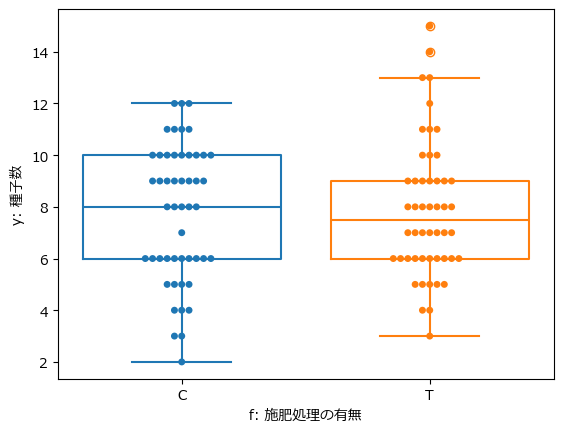

In [19]:
# 箱ひげ図の描画 p.45 図3.3

# 箱ひげ図の描画
sns.boxplot(data=data, x='f', y='y', hue='f', fill=False)
# スウォームプロットの重ね描き
sns.swarmplot(data=data, x='f', y='y', hue='f')
# 修飾：x軸・y軸ラベル
plt.gca().set(xlabel='f: 施肥処理の有無', ylabel='y: 種子数');

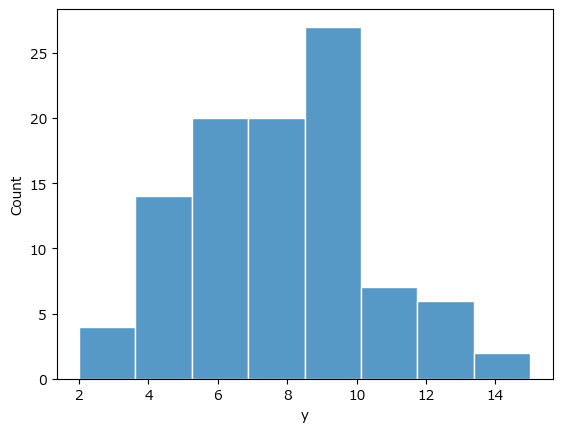

In [20]:
# 種子数のヒストグラム
sns.histplot(data=data, x='y', edgecolor='white');

# リンク関数と線形予測子

## 基本

リンク関数は対数、線形予測子はβ1+β2xi
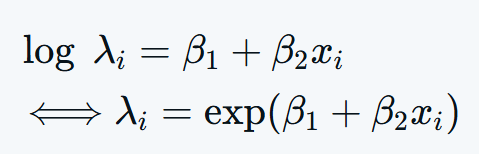  
λをexp(線形予測子)で表現できる

ですって
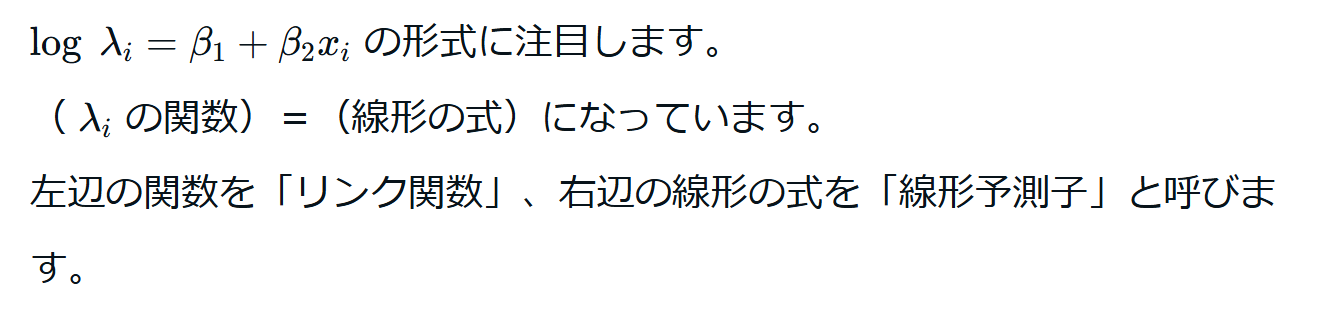  
リンク関数がlogなら、対数リンク関数と呼ぶ。

## ポワソン回帰で対数リンク関数を用いる理由

λ=exp(線形予測子)の形になり、λが非負である条件を満たせるから。  
GLMを扱うライブラリでもポワソン分布を指定するとデフォルトで対数リンク関数を使うらしい

## 図示してみよう

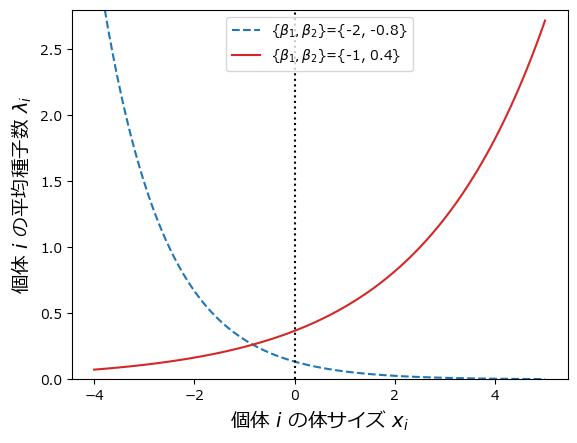

In [24]:
# 個体iの平均種子数λiと体サイズx_iの関係 p.48 図3.4

## 設定
beta1s = [-2, -1]                 # 切片β1
beta2s = [-0.8, 0.4]              # 傾きβ2
colors = ['tab:blue', 'tab:red']  # グラフの線の色
linestyles = ['--', '-']          # グラフの線種
x_val = np.linspace(-4, 5, 101)   # x_iの値

## 描画
# ２組のパラメータごとにlam算出とグラフ描画を繰り返し処理
for beta1, beta2, color, linestyle in zip(beta1s, beta2s, colors, linestyles):
    # lam算出
    lam_val = np.exp(beta1 + beta2 * x_val)
    # 折れ線グラフの描画
    plt.plot(x_val, lam_val, c=color, ls=linestyle,
             label=rf'{{$\beta_1, \beta_2$}}={{{beta1}, {beta2}}}')
# x_i=0の垂直線の描画
plt.axvline(0, color='black', ls=':')
# 修飾：y軸の範囲、x軸ラベル、y軸ラベル、凡例
plt.ylim(0, 2.8)
plt.xlabel('個体 $i$ の体サイズ $x_i$', fontsize=14)
plt.ylabel('個体 $i$ の平均種子数 $\lambda_i$', fontsize=14)
plt.legend(loc='upper center');

赤線の切片-1はx=0のときにλ=e^(-1)になる（＝0.36）

# 当てはめ＆評価

## 対数尤度logLが最大になるβ1,β2は？

logL=func(λ)で、
λ=func(β1,β2)

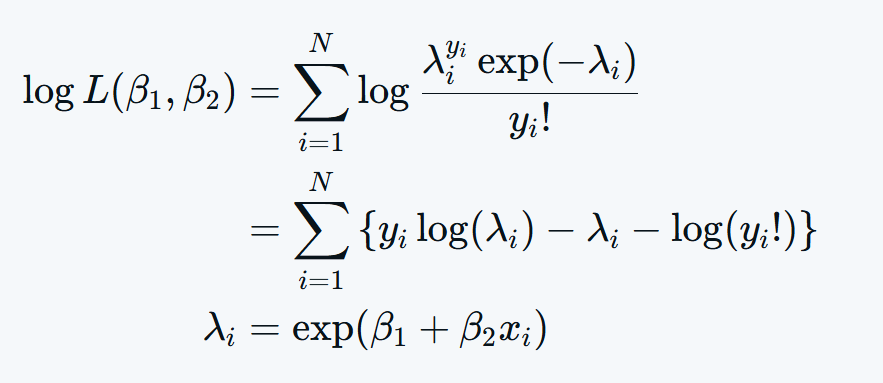

In [25]:
# 統計モデルの当てはめ ※statsmodelsのglmを利用 p.49, 50

# 確率分布とリンク関数の設定
# ※ポアソン分布の場合、リンク関数のデフォルトは対数 Log（省略可能）
family = sm.families.Poisson(link=sm.families.links.Log())

# GLMの実行 ※formulaに線形予測子を指定
result = smf.glm(formula='y ~ x', data=data, family=family).fit()

# GLMの結果表示
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -235.39
Date:                Mon, 03 Nov 2025   Deviance:                       84.993
Time:                        09:01:06   Pearson chi2:                     83.8
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04414
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2917      0.364      3.552      0.000       0.579       2.005
x              0.0757      0.036      2.125      0.034       0.006       0.145
==============================================================================
"""

In [26]:
# 係数の推定値
print('beta_1:', result.params.Intercept)
print('beta_2:', result.params.x)

beta_1: 1.291720838642378
beta_2: 0.07566191454072188


In [27]:
# 標準誤差の推定値
print('beta_1:', result.bse.Intercept)
print('beta_2:', result.bse.x)

beta_1: 0.36368658448685415
beta_2: 0.03560420316958474


In [28]:
# z値 ※属性名はtvaluesですが、summary()のzを取得できます
print('beta_1:', result.tvalues.Intercept)
print('beta_2:', result.tvalues.x)

beta_1: 3.5517417846603814
beta_2: 2.12508377677602


In [29]:
# p値 
print('beta_1:', result.pvalues.Intercept)
print('beta_2:', result.pvalues.x)

beta_1: 0.00038269021251646394
beta_2: 0.033579623019838654


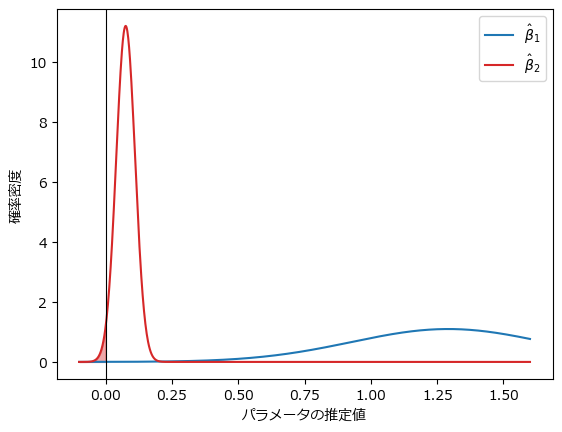

In [30]:
### パラメータ推定値のばらつきの評価 p.52 図3.6

## 設定
x_val = np.linspace(-0.1, 1.6, 1001)  # x軸の値
x_val_0 = np.linspace(-0.1, 0, 101)   # x軸の0未満の値（塗りつぶし用）

## 正規分布の確率密度関数の算出 ※bse: パラメータ推定値の標準誤差
# β1
beta1_y_val = stats.norm.pdf(
    x_val, loc=result.params.Intercept, scale=result.bse.Intercept)
# β2
beta2_y_val = stats.norm.pdf(x_val, loc=result.params.x, scale=result.bse.x)
# β2（塗りつぶし用）
beta2_y_val_0 = stats.norm.pdf(x_val_0, loc=result.params.x, scale=result.bse.x)

## 描画
# β1の確率密度関数の描画
plt.plot(x_val, beta1_y_val, color='tab:blue', label=r'$\hat{\beta}_1$')
# β2の確率密度関数の描画
plt.plot(x_val, beta2_y_val, color='tab:red', label=r'$\hat{\beta}_2$')
# β2のx<=0の領域の塗りつぶし描画
plt.fill_between(x_val_0, beta2_y_val_0, 0, color='tab:red', alpha=0.4)
# x=0の垂直線の描画
plt.axvline(0, color='black', lw=0.8)
# 修飾
plt.xlabel('パラメータの推定値')
plt.ylabel('確率密度')
plt.legend();

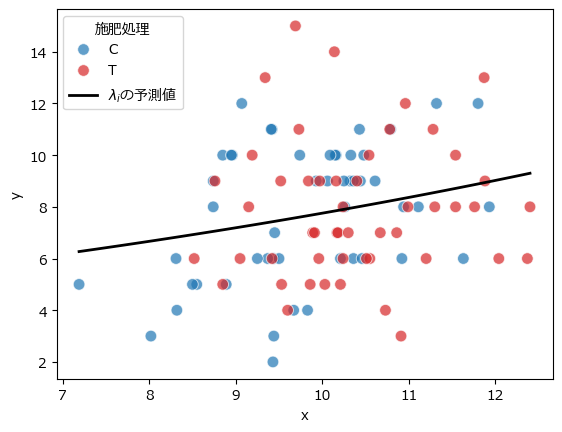

In [31]:
# 平均種子数λiの予測の可視化 p.53, 54 図3.7 λの数式で計算

## 設定
beta1_hat, beta2_hat = result.params                  # β1、β2の推定値
x_val = np.linspace(data.x.min(), data.x.max(), 100)  # x軸の値

## λiの予測値の算出 ※ λi = exp(β1 + β2 * x) <= テキストの数式
lam_hat1 = np.exp(beta1_hat + beta2_hat * x_val)

## 描画
# x,yの観測値の散布図の描画
sns.scatterplot(data=data, x='x', y='y', hue='f', 
                palette=['tab:blue', 'tab:red'], s=70, alpha=0.7)
# λiの予測値の描画
plt.plot(x_val, lam_hat1, color='black', lw=2, label='$\lambda_i$の予測値')
# 凡例
plt.legend(loc='upper left', title='施肥処理');

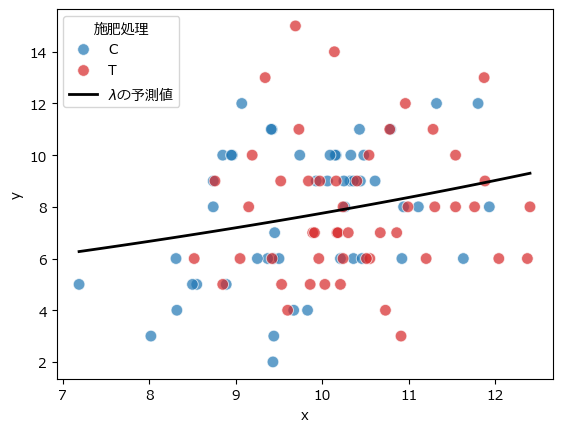

In [32]:
# 平均種子数λの予測の可視化 p.53, 54 図3.7 predictで計算

## 設定
beta1_hat, beta2_hat = result.params                  # β1、β2の推定値
x_val = np.linspace(data.x.min(), data.x.max(), 100)  # x軸の値

## λの予測値の算出 ※ result に対して predictメソッドで予測
lam_hat2 = result.predict(dict(x=x_val)).values  # 変数名xを与える目的で辞書化

## 描画
# x,yの観測値の散布図の描画
sns.scatterplot(data=data, x='x', y='y', hue='f', 
                palette=['tab:blue', 'tab:red'], s=70, alpha=0.7)
# λの予測値の描画
plt.plot(x_val, lam_hat2, color='black', lw=2, label='$\lambda$の予測値')
# 凡例
plt.legend(loc='upper left', title='施肥処理');

In [33]:
# λの計算値とget_predictメソッドの予測値は等しい
lam_hat1 - lam_hat2

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

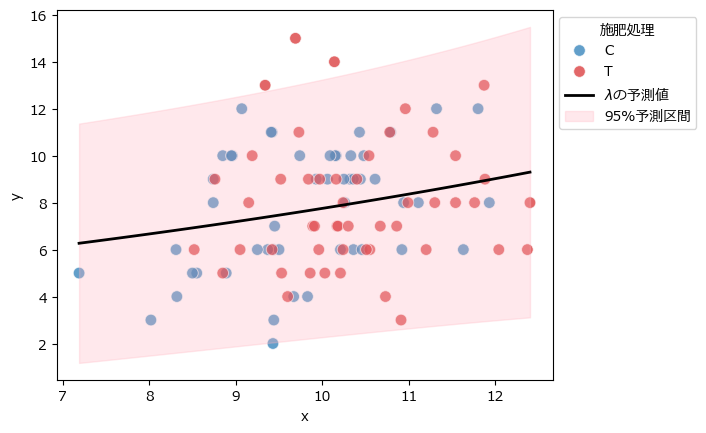

In [34]:
# 95% 予測区間（の近似値）をあわせて描画

## 予測の実行
# 予測の実行：summaryに実行結果を格納
pred = result.get_prediction(dict(x=x_val))
summary = pred.summary_frame()
# 平均 λ の予測値・平均の予測値の標準誤差（パラメータの不確実性）の取得
mean_pred = summary['mean'].values
se_mean = summary['mean_se'].values

## 平均 λ の予測値の標準誤差の算出
# 平均の予測値の分散の算出 ※正規分布近似前提の線形化した近似です
# (平均の予測値の標準誤差)² + 目的変数の分散（ポアソン分布の分散は予測平均に等しい）
var_pred = se_mean**2 + mean_pred
# 平均の予測値の標準誤差の算出
se_pred = np.sqrt(var_pred)

## 目的変数 y の95%予測区間の算出
ppt = stats.norm.isf(q=0.025)      # 標準正規分布の上側 2.5%点 ≈ 1.96
lower = mean_pred - ppt * se_pred  # 95% 信頼区間の下端
upper = mean_pred + ppt * se_pred  # 95% 信頼区間の上端

## 描画
# x,yの観測値の散布図の描画
sns.scatterplot(data=data, x='x', y='y', hue='f', 
                palette=['tab:blue', 'tab:red'], s=70, alpha=0.7)
# λの予測値の描画
plt.plot(x_val, mean_pred, color='black', lw=2, label='$\lambda$の予測値')
# yの95%予測区間の塗りつぶし描画
plt.fill_between(x_val, lower, upper, color='lightpink', alpha=0.3,
                 label='95%予測区間')
# 凡例
plt.legend(bbox_to_anchor=(1, 1), title='施肥処理');